# Основы PyTorch и архитектуры нейросетей

**Цель**:
- освоить базовые операции с тензорами и механизмы автоматического дифференцирования;
- научиться создавать полносвязные, свёрточные и рекуррентные модели с использованием `torch.nn.Module`;
- понять общий пайплайн обучения: данные -> модель -> функция потерь -> оптимизатор -> цикл обучения.

Задание заточено на знакомство с библиотекой `pytorch` и навыками построения моделей глубинного обучения. И для его выполнения потребуется графический процессор.

`PyTorch` $-$ современная библиотека глубинного обучения, развивающаяся под крылом Facebook. Она не похожа на другие популярные библиотеки, такие как `Caffe`, `Theano` или `TensorFlow`. Она позволяет исследователям воплощать в жизнь свои самые смелые фантазии, а инженерам с лёгкостью эти фантазии имплементировать.

`PyTorch` немного похож на `numpy`: он тоже использует в своей основе массивы, которые называются `тензорами`. По сути, тензоры $-$ то же самое, что и `numpy.ndarray`, просто другой тип данных. Однако большинство операций, доступных для работы с тензорами, одинаково или почти похоже называются и в `pytorch`, и в `numpy`.

Почему же тогда исследователи (и мы вслед за ними) используют для нейронных сетей именно `torch`, а не `numpy`. В отличие от второго, `torch` позволяет запускать сложные матричные вычисления, лежащие в основе всех нейронных сетей, на графическом процессоре, а также легко считает градиенты.

Почему нужен графический процессор (`GPU`), а не обычный процессор? Дело в том, что матричные вычисления, кроме как в нейронных сетях, используются в графике компьютерных игр. Чтобы игры работалт быстрее, нужны эффективные способы считать матрицы и <strike>прямые руки программистов</strike> мощные видеокарты, которые эти вычисления обеспечивают. Развитие игровой индустрии привело к развитию графических процессоров, за что мы горячо благодарны всем геймерам мира.

Посмотрим, как использовать библиотеку по её прямому назначению. Здесь можете ознакомиться с <a href=https://pytorch.org/docs/stable/>документацией</a>.

## Блок 1. Основы PyTorch и автоградиент
### 1. Мастерство работы с тензорами
Тензор $-$ фундамент `PyTorch`. Важно понимать не только создание, но и управление памятью, размещение на устройствах и тонкости изменения формы.
#### 1.1 Базовые операции
Создайте тензоры:

In [2]:
import sys
print(sys.executable)

C:\Users\79300\anaconda3\python.exe


In [2]:
import torch

# из списка
a = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32) # у торча есть своя система типов, обратите внимание
# тензор из случайных чисел
b = torch.randn(2, 2)
# тензор из единиц
c = torch.ones(2, 2)

Выполните поэлементное сложение, матричное умножение и измените форму тензора `a` в вектор (4 элемента).

In [4]:
vectors_addition = a + b + c
print(f'Сложение: {vectors_addition}')
vectors_matrix = a @ b @ c
print(f'Матричное умножение: {vectors_matrix}')
vector_a_reshape = a.reshape(4)
print(f'Вектор а: {vector_a_reshape}')

Сложение: tensor([[2.3891, 1.2484],
        [4.9549, 6.4995]])
Матричное умножение: tensor([[3.5463, 3.5463],
        [5.7301, 5.7301]])
Вектор а: tensor([1., 2., 3., 4.])


#### 1.2 Изменение формы и работа с памятью
Создайте тензор размером `(2, 3, 4)` из случайных чисел. Измените его форму на (3, 8) с помощью `.view()` и `.reshape()`. После этого измените исходный тензор `inplace` с помощью `.resize()`.

В каком случае `view()` вызовет ошибку,  а `reshape()` $-$ нет? Создайте несмежный тензор с помощью транспонирования и проверьте `.is_contiguous()`.

In [5]:
vector = torch.randn(2, 3, 4)
vector_view = vector.view(3, 8)
print(f'Вектор с использованием view:\n {vector_view}')
vector_reshape = vector.reshape(3, 8)
print(f'Вектор с использованием reshape:\n {vector_reshape}')
vector.resize(3, 8)
print(f'Новая форма вектора с использованием resize:\n {vector}')

vector = torch.randn(2, 3, 4)
trans_vector = vector.transpose(1, 2)
print(f"Исходный тензор смежный: {vector.is_contiguous()}")
print(f"Транспонированный тензор смежный: {trans_vector.is_contiguous()}")
# ПРОБУЕМ VIEW НА ТРАНСПОНИРОВАННОМ 
try:
    trans_view = trans_vector.view(3, 8)
    print('yeap')
except RuntimeError as e:
    print(f'Ошибка: {e}')
# ПРОБУЕМ RESHAPE
trans_reshape = trans_vector.reshape(3, 8)
print(f'Транспонированный вектор с reshape:\n {trans_reshape}')    

Вектор с использованием view:
 tensor([[ 1.9118,  0.3660, -1.0362,  0.0334,  1.3743,  0.8198,  1.0371, -0.6035],
        [ 0.2199, -0.6693, -1.6248,  1.7144,  0.0214,  0.1019, -0.2790, -1.0567],
        [ 1.0960,  0.1770,  0.7828, -0.9996,  1.2227, -1.5735, -0.9556, -2.0456]])
Вектор с использованием reshape:
 tensor([[ 1.9118,  0.3660, -1.0362,  0.0334,  1.3743,  0.8198,  1.0371, -0.6035],
        [ 0.2199, -0.6693, -1.6248,  1.7144,  0.0214,  0.1019, -0.2790, -1.0567],
        [ 1.0960,  0.1770,  0.7828, -0.9996,  1.2227, -1.5735, -0.9556, -2.0456]])
Новая форма вектора с использованием resize:
 tensor([[[ 1.9118,  0.3660, -1.0362,  0.0334],
         [ 1.3743,  0.8198,  1.0371, -0.6035],
         [ 0.2199, -0.6693, -1.6248,  1.7144]],

        [[ 0.0214,  0.1019, -0.2790, -1.0567],
         [ 1.0960,  0.1770,  0.7828, -0.9996],
         [ 1.2227, -1.5735, -0.9556, -2.0456]]])
Исходный тензор смежный: True
Транспонированный тензор смежный: False
Ошибка: view size is not compatible wit

C:\Users\79300\anaconda3\lib\site-packages\torch\_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


#### 1.3 Broadcasting и умные операции
Даны два тензора: `x` размером `(5, 1)` и `y` размером `(1, 4)`. Получите результа `x + y` и объясните, как работает broadcasting.

In [6]:
x = torch.randn(5, 1)
y = torch.randn(1, 4)
result = x + y
print(result)
print(result.shape)

tensor([[-0.5967,  0.6126, -0.6278,  0.1768],
        [-0.3708,  0.8385, -0.4019,  0.4026],
        [-1.5497, -0.3405, -1.5809, -0.7763],
        [-0.1290,  1.0803, -0.1601,  0.6445],
        [-0.7586,  0.4506, -0.7898,  0.0148]])
torch.Size([5, 4])


Broadcasting я уже использовал в не помню какой задаче, но тоже растягивал вектора.
В общем broadcasting по факту "растягивает" меньший тензор, чтобы они стали одинакового размера. По сути есть два правила: или размерности будут равны или какая-то из размерностей вектора будет 1, в таком случае его растягивают до максимума.
Например у меня 5,1 вектор - у него есть 1 и мы его растягиваем до 5. Вектор 1,4 - есть 1 и растягиваем до 4. В сумме получаем тензор 5,4 (что и получилось в выводе)

#### 1.4 Перемещение данных между CPU и GPU

In [7]:
# проверьте доступность CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство {device}")

Используется устройство cuda


In [3]:
torch.cuda.is_available()

True

In [22]:
# создайте тензор на CPU и перенесите на GPU 
your_cpu_tensor = torch.randn(1000, 1000)
print(your_cpu_tensor)
gpu_tensor = your_cpu_tensor.to(device)

tensor([[ 1.2641,  2.8354, -1.3024,  ..., -1.0386, -0.5396, -1.6794],
        [-2.1674, -0.6289, -0.5633,  ..., -1.4522, -1.5895,  0.0377],
        [-0.1661, -0.5980,  0.5856,  ...,  0.3885,  0.6536,  0.4168],
        ...,
        [ 0.4011,  0.4085,  1.4015,  ..., -2.0224, -0.6226,  0.2317],
        [-0.2056,  0.2598,  0.2625,  ..., -0.1886, -0.6291,  0.6702],
        [-0.5312,  2.5429, -0.5603,  ...,  0.8977, -1.2567, -1.0408]])


In [24]:
# выполните матричное умножение на GPU и замерьте время
import time
start = time.time()
result = gpu_tensor @ gpu_tensor.reshape(1000, 1000)
torch.cuda.synchronize() # дождаться завершения GPU операций
print(f"Время на GPU: {time.time() - start:.4f} сек")

Время на GPU: 0.0050 сек


In [26]:
# сравните с CPU, есть ли разница
start = time.time()
result_cpu = your_cpu_tensor @ your_cpu_tensor.reshape(1000, 1000)
cpu_time = time.time() - start
print(f"Время на CPU: {cpu_time:.4f} сек")

Время на CPU: 0.0070 сек


### 2. Autograd $-$ автоматическое дифференцирование
Автоматическое дифференцирование $-$ сердце `PyTorch`. Важно уметь управлять графом вычислений.
#### 2.1 Вычисление градиентов для произвольной функции
Найдите градиент функции $$ f(x, y) = x^3 + 3xy^2$$ в точке `(2,3)`, используя метод `backward()`

In [33]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

f = x**3 + 3 * x * y**2
f.backward()

print(f"df/dx = {x.grad}")  # ожидаем 3*4 + 3*9 = 12+27=39
print(f"df/dy = {y.grad}")  # ожидаем 6*x*y = 36

df/dx = 39.0
df/dy = 36.0


Теперь сбросим градиенты:

In [35]:
x.grad.zero_()
y.grad.zero_()

tensor(0.)

Вычислите вторую производную $\frac{\mathrm{d}^2 f}{\mathrm{d} x^2}$ с помощью `create_graph=True`:

In [38]:
x = torch.tensor(2.0, requires_grad=True)
f = x**3 + 3 * x * y**2 # вообще можно было убрать 3xy2 т.к. y2 константа по x
first = torch.autograd.grad(f, x, create_graph=True)[0]
second = torch.autograd.grad(first, x)[0]

print(second)

tensor(12.)


#### 2.2 Функции `detach` и `no_grad`

Дана модель с одним линейным слоем:

In [39]:
lin = torch.nn.Linear(10, 1)

# генерация входных данных
x = torch.randn(5, 10, requires_grad=True)
out = lin(x).sum()
out.backward()

Теперь мы хотим использовать выход модели для чего-то ещё, но не хотим, чтобы градиенты текли обратно в модель. Как это сделать?

In [41]:
out_out_out = out.detach()
# no_grad надо использовать внутри какого-то блока, чтобы операция не записывалась в граф, а detach(), когда надо отцепить тензор от графа

#### 2.3 Визуализация графа вычислений
Установите `torchviz` и `graphviz`.

In [42]:
!pip install torchviz

     ---------------------------------------- 47.3/47.3 kB 1.2 MB/s eta 0:00:00


In [6]:
import os

os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"
import subprocess
try:
    subprocess.run(["dot", "-version"], check=True)
    print("✅ Graphviz найден!")
except:
    print("❌ Graphviz не найден. Проверьте путь установки")

✅ Graphviz найден!


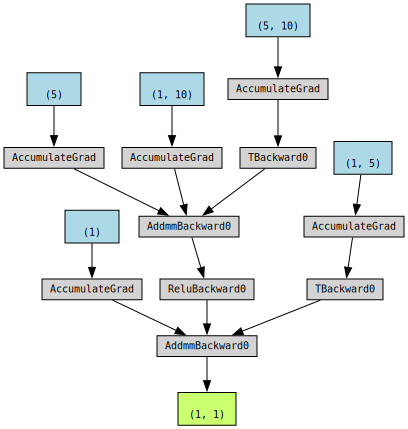

In [5]:
from torchviz import make_dot
import torch

x = torch.randn(1, 10, requires_grad=True)
y = torch.nn.Linear(10, 5)(x)
y = torch.relu(y)
z = torch.nn.Linear(5, 1)(y)
# используя make_dot, нарисуйте граф, отражающий поток данных и градиентов

make_dot(z)

### 3. Углублённая работа с `nn.Module`

Понимание внутреннего устройства модулей необходимо для создания сложных архитектур.

#### 3.1 Кастомный слой с обучаемыми параметрами
Создайте слой, реализующий операцию `y = A * x + b`, где `A` $-$ диагональная матрица, а `b` $-$ вектор. Поясню: вам необходимо создать класс (пусть будет `DiagonalLinear`), наследующий классу `torch.nn.Module`. Параметры слоя должны обучаться и должны быть зарегистрированы через `nn.Parameter`.

In [8]:
import torch
import torch.nn as nn

class DiagonalLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.A = nn.Parameter(torch.randn(out_features, in_features))
        self.b = nn.Parameter(torch.randn(out_features))
        
    def forward(self, x):
        return x * self.A + self.b

#### 3.2 Регистрация буферов (необучаемых тензоров)
Добавьте в свой слой скользящее среднее активаций (running mean), которое обновляется во время выполнения метода `forward`, но не участвует в градиентном спуске.

Формула скользящего среднего: $$\mu_{running} = (1 - momentum) * \mu_{running} + \mu_{batch} * momentum$$

In [19]:
import torch
import torch.nn as nn

class DiagonalLinear(nn.Module):
    def __init__(self, in_features, out_features, momentum = 0.1):
        super().__init__()
        self.A = nn.Parameter(torch.randn(out_features, in_features))
        self.b = nn.Parameter(torch.randn(out_features))
        self.register_buffer('running_mean', torch.zeros(out_features)) # тензор, сохраняющийся в модели + не требует градиентов 
        self.momentum = momentum
        
    def forward(self, x):
        out = x @ self.A.T + self.b
        batch = out.mean(dim=0)
        with torch.no_grad():
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch
        return out    
        

In [21]:
layer = DiagonalLinear(in_features=3, out_features=2, momentum=0.1)

print("Параметры (обучаемые):")
for name, param in layer.named_parameters():
    print(f"  {name}: {param.shape}")

print("\nБуферы (необучаемые):")
for name, buffer in layer.named_buffers():
    print(f"  {name}: {buffer.shape}")

# прогоняю данные
x = torch.randn(4, 3)
out = layer(x)

print(f"\nВход: {x.shape}")
print(f"Выход: {out.shape}")
print(f"running_mean после forward: {layer.running_mean}")

Параметры (обучаемые):
  A: torch.Size([2, 3])
  b: torch.Size([2])

Буферы (необучаемые):
  running_mean: torch.Size([2])

Вход: torch.Size([4, 3])
Выход: torch.Size([4, 2])
running_mean после forward: tensor([ 0.0542, -0.0218])


#### 3.3 Инициализация весов
Напишите функцию, которая инициализирует веса линейных слоёв по Ксавье, а свёрточных $-$ по Каймингу.


In [23]:
def init_weihgts(m):
    
    if isinstance(m, nn.Linear): # ксавье / linear - линейный слой
        nn.init.xavier_uniform_(m.weight) # limit = sqrt(6 / in_f + out_f) - равномерное распределение
        if m.bias is not None:
            nn.init.zeros_(m.bias)
            
    elif isinstance(m, nn.Conv2d): # кайминг / conv2d - сверточный слой
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu') # limit = sqrt (6 / in) - кайминг использует онли кол-во входов
        if m.bias is not None:
            nn.init.zeros_(m.bias)

## Блок 2. Разработка полносвязной нейронной сети на PyTorch
**Какая цель**: создать полноценный пайплайн обучения классификатора изображений на 10 классов с использованием только полносвязных слоёв, освоив при этом ключевые возможности PyTorch: от управления данными и кастомных компонентов до профилирования и экспорта модели.

**Данные**: <a href=https://www.kaggle.com/datasets/alessiocorrado99/animals10>Animals-10</a>

**Описание**:
- Около 28 000 цветных изображений среднего качества;
- 10 классов: `dog`, `cat`, `horse`, `spyder`, `butterfly`, `chicken`, `sheep`, `cow`, `squirrel`, `elephant`;
- Количество изображений в каждом классе варьируется от 2 000 до 5 000 (несбалансированный набор);
- Присутствует некоторый шум (ошибочные изображения), что приближает задачу к реальным условиям;
- Данные организованы по папкам: корневая папка `raw-img/`, внутри подпапки с именами классов.

**Что делать**: 
- необходимо привести все изображения к одному размеру (например, $64\times64$);
- для уменьшения числа параметров можно конвертировать в градации серого (1 канал), тогда входной слой: $64\times64 = 4096$ нейронов;
- так как классов 10, выходной слой будет иметь 10 нейронов, функция потери $-$ `CrossEntropyLoss`;
- учитывая несбалансированность классов, желательно вычислять взвешенную точность (`accuracy`) или использовать веса классов в функции потерь.

### Этап 1. Настройка окружения и загрузка данных с кастомным `Dataset`

1. Установите библиотеки `torch`, `torchvision`, `pillow\openCV`, `matplotlib`, `tqdm`, `torchviz`.
2. Создайте класс `AnimalDataset`, унаследованный от `torch.utils.data.Dataset`:
    - в конструкторе принимает путь к корневой папке с подпапками классов и флаг `train` (для разделения `train/val`);
    - сканирует папки, собирает пути ко всем изображениям и соответствующие метки (целые числа от 0 до 9);
    - создаёт словарь `class_to_idx` для отображения имени папки в индекс;
    - применяет аугментации только для обучающей выборки (например, случайное горизонтальное отражение, поворот, изменение яркости). Для валидации $-$ только ресайз, преобразование в тензор и нормализация;
    - реализует метод `__len__` и `__getitem__`. 

In [47]:
!pip install pillow

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)


100%|███████████████████████████████████████████████████████████████████████████████| 586M/586M [03:59<00:00, 2.57MB/s]

Extracting files...


Path to dataset files: C:\Users\79300\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2


In [83]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os
import sys
import kagglehub

# путь к папкам
raw_img_path = os.path.join(path, "raw-img")

# добавляю путь к translate.py
sys.path.insert(0, path)
from translate import translate

class AnimalDataset(Dataset):
    def __init__(self, root_dir, train=True, val_split=0.2, seed=42):
        self.train = train
        
        # классы
        self.classes = sorted([d for d in os.listdir(root_dir) 
                                if os.path.isdir(os.path.join(root_dir, d))]) # проверяем, является ли склеенный путь (путь + название якобы директория d) папкой
        
        # маппинг итальянских названий в индексы
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}
        
        # собираю все пути к изображениям и метки
        all_images, all_labels = [], [] # images - пути, labels - метки от 0 до 9 - 10 папок
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name) # собираю фулл путь к папке класса
            class_idx = self.class_to_idx[class_name] # получаю числовой индекс
            
            for img_file in os.listdir(class_path): # перебираю в папке класса все файлы
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')): # если у него конец расширении ( или разрешении.., не помню :D ) - значит фотка
                    all_images.append(os.path.join(class_path, img_file)) # добавляю фулл путь к изображению в список
                    all_labels.append(class_idx) # добавляю метку от 0 до 9 в список
        
        # Разделяем на train/val
        torch.manual_seed(seed) # перемешивание будет всегда одинаковым в зависимости от seed при определении
        indices = torch.randperm(len(all_images)) # случайно перестанавливаю индексы
        val_size = int(len(all_images) * val_split) # размер валидациоонной выборки (val_split сейчас 0.2 = 20%)
        
        if train: 
            self.images = [all_images[i] for i in indices[val_size:]] # элементы с val_size -> до конца
            self.labels = [all_labels[i] for i in indices[val_size:]] # элементы с val_size -> до конца
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)), # изменяю размер
                transforms.RandomHorizontalFlip(), # случайное отражение по горизонтали
                transforms.RandomRotation(15), # случайный поворот на 15 градусов
                transforms.ColorJitter(brightness=0.2), # случайная яркость
                transforms.ToTensor(), # ту тензор :p
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализуем x_norm = (x - mean) / std
            ])
        else:
            self.images = [all_images[i] for i in indices[:val_size]] # элементы от начала -> до val_size
            self.labels = [all_labels[i] for i in indices[:val_size]] # элементы от начала -> до val_size
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
    
    def __len__(self): # размер датасета
        return len(self.images)
    
    def __getitem__(self, idx): # возвращает элеменет по индекус
        image = Image.open(self.images[idx]).convert('RGB') # открываем файл по пути, затем убеждаемся что это РГБ
        return self.transform(image), self.labels[idx] # трансформер оптимус. изображение, метка

# Использование
train_ds = AnimalDataset(raw_img_path, train=True)
val_ds = AnimalDataset(raw_img_path, train=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Классы: {train_ds.classes}")
print(f"Английские названия: {[translate.get(c, c) for c in train_ds.classes]}")

Train: 20944, Val: 5235
Классы: ['cane', 'elefante', 'farfalla', 'gallina', 'gatto', 'horse', 'mucca', 'ragno', 'scoiattolo', 'sheep']
Английские названия: ['dog', 'elephant', 'butterfly', 'chicken', 'cat', 'horse', 'cow', 'spider', 'squirrel', 'sheep']


3. Определите трансформации:
    - обучающая выборка: ресайз до $64\times64$, конвертация в градации серого, случайные аугментации, преобразование в тензор, нормализация;
    - валидационная: только ресайз, градации серого, тензор, нормализация

Для этого почитайте документацию к `torchvision.transforms`.

In [ ]:
import torchvision.transforms as transforms

# ваше решение здесь

4. Создайте `DataLoader` с `batch_size=64` (или 128, тоже можно).

In [ ]:
# ваше решение здесь

### Этап 2. Создание модели с использованием продвинутых возможностей `nn.Module`
Разработайте класс `AnimalFC` $-$ глубокая полносвязная сеть для классификации 10 видов.

**Предлагаемая архитектура**:
- вход: 4096 ($64\times64\times1$);
- скрытые слои: 2048 --> 1024 --> 512 --> 256 --> 128;
- после каждого скрытого слоя: `BatchNorm1d` + `ReLU` + `Dropout(0.3)`;
- выходной слой: 10 нейронов (без активации, так как используется `CrossEntropyLoss`).

In [ ]:
# ваше решение здесь

**Дальше**:
- замените один из линейных слоёв на ваш кастомный слой `DiagonalLinear`, чтобы продемонстрировать создание слоя с обучаемой диагональной матрицей;
- вставьте слой `LayerWithStats`, который отслеживает скользящее среднее активаций после определённого слоя. Это полезно для мониторинга распределений во время обучения.

### Обучение модели с кастомными компонентами
#### 3.1 Функция потерь
- основная: `nn.CrossEntropyLoss`;
- учитывая несбалансированность классов, можно вычислить веса классов и передать их в `CrossEntropyLoss(weight=class_weights)`.

#### 3.2 Оптимизатор и планировщик
- оптимизатор: `torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)`;
- планировщик: `ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)`.

#### 3.3 Цикл обучения
Реализуйте функции `train_epoch` и `validate`:
- в `train_epoch`: модель в режим `model.train()`, для каждого батча $-$ прямой проход, вычисление `loss`, `backward()`, `optimizer.step()`, `optimizer.zero_grad()`;
- в `validate`: модель в режим `model.eval()`, с `torch.no_grad()` вычисляются `loss` и `accuracy`;
- отслеживайте точность (accuracy) для мультиклассовой классификации: `(preds.argmax(dim=1) == labels).float().mean()`;
- сохраняйте `state_dict` модели с наилучшей валидационной точностью.

### Этап 4. Анализ и профилирование
1. Запустите профилировщик для одного батча, чтобы определить узкие места:

In [ ]:
with torch.autograd.profiler.profile(use_cuda=True) as prof:
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

Ожидается, что основные затраты времени придутся на матричные умножения в линейных слоях.

2. Для `DiagonalLinear` выполните `torch.autograd.gradcheck`:

In [ ]:
from torch.autograd import gradcheck
layer = DiagonalLinear(5).double()
input_tensor = torch.randn(3, 5, requires_grad=True, dtype=torch.double)
test = gradcheck(layer, input_tensor, eps=1e-6, atol=1e-4)
print("Gradient check passed:", test)

3. **Визуализация обучения**:
    - построить график `loss` на train и val по эпохам;
    - построить график `accuracy` на train и val по эпохам;
    - построить график `learning_rate` по эпохам.

In [ ]:
# ваше решение здесь